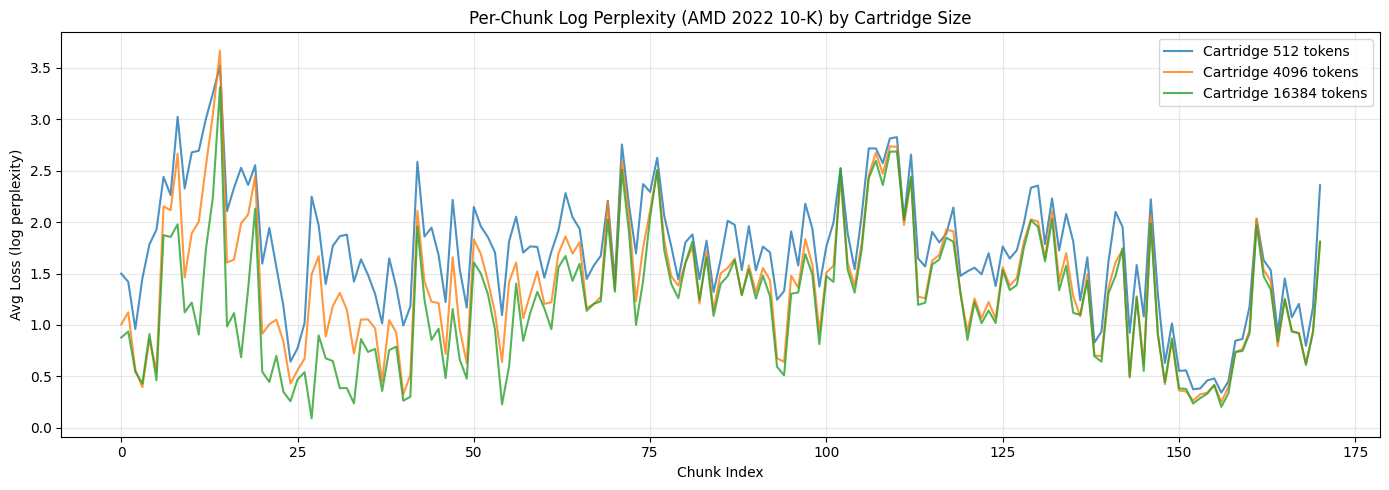

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load the three results
paths = {
    512:   "/Users/S102591/Desktop/research-work/cartridges/outputs/chunk_perplexity_512.json",
    4096:  "/Users/S102591/Desktop/research-work/cartridges/outputs/chunk_perplexity_4096.json",
    16384: "/Users/S102591/Desktop/research-work/cartridges/outputs/chunk_perplexity_16384.json",
}

data = {}
for size, path in paths.items():
    with open(path) as f:
        data[size] = json.load(f)

# Plot chunk_idx vs avg_loss (log perplexity) for each cartridge size
fig, ax = plt.subplots(figsize=(14, 5))

for size, d in data.items():
    results = d["results"]
    chunk_idxs = [r["chunk_idx"] for r in results]
    avg_losses = [r["avg_loss"] for r in results]
    ax.plot(chunk_idxs, avg_losses, label=f"Cartridge {size} tokens", alpha=0.8)

ax.set_xlabel("Chunk Index")
ax.set_ylabel("Avg Loss (log perplexity)")
ax.set_title("Per-Chunk Log Perplexity (AMD 2022 10-K) by Cartridge Size")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

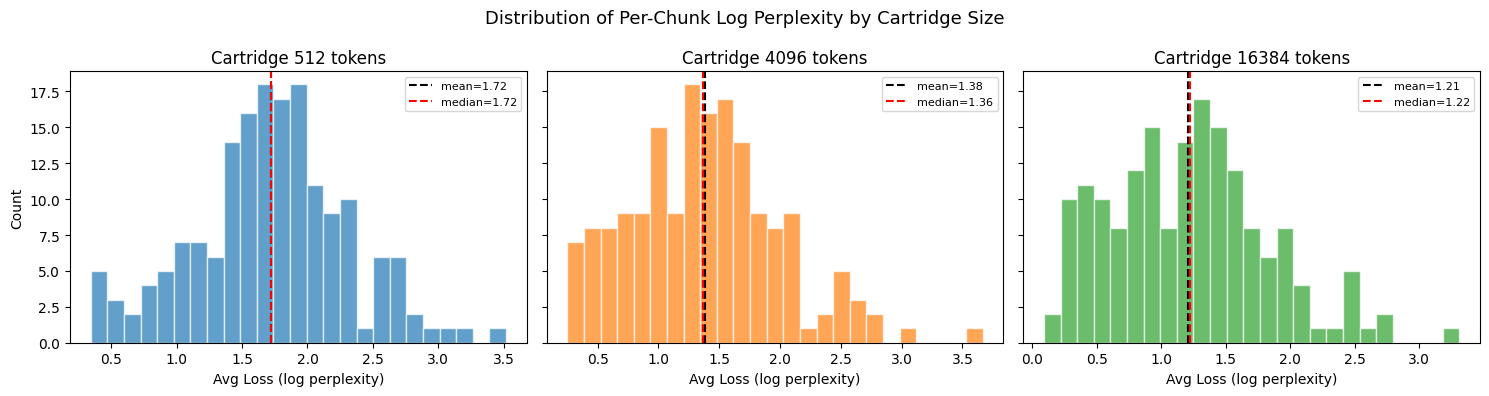

In [2]:
# Distribution of avg_loss (log perplexity) for each cartridge size
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

colors = {512: "tab:blue", 4096: "tab:orange", 16384: "tab:green"}

for ax, (size, d) in zip(axes, data.items()):
    avg_losses = [r["avg_loss"] for r in d["results"]]
    ax.hist(avg_losses, bins=25, color=colors[size], alpha=0.7, edgecolor="white")
    ax.axvline(np.mean(avg_losses), color="black", linestyle="--", label=f"mean={np.mean(avg_losses):.2f}")
    ax.axvline(np.median(avg_losses), color="red", linestyle="--", label=f"median={np.median(avg_losses):.2f}")
    ax.set_xlabel("Avg Loss (log perplexity)")
    ax.set_title(f"Cartridge {size} tokens")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Count")
fig.suptitle("Distribution of Per-Chunk Log Perplexity by Cartridge Size", fontsize=13)
plt.tight_layout()
plt.show()

Pairwise Spearman Rank Correlation (avg_loss across chunks):

  Cartridge   512 vs  4096:  rho = 0.9233,  p = 3.68e-72
  Cartridge   512 vs 16384:  rho = 0.7641,  p = 5.33e-34
  Cartridge  4096 vs 16384:  rho = 0.9121,  p = 2.50e-67


/var/folders/r3/9pyjwcw15rvd_v6nj7_jv51c0000gp/T/ipykernel_82181/682221522.py:42: RuntimeWarning: divide by zero encountered in log10
  log_pvals = np.where(pval_matrix > 0, np.log10(pval_matrix), 0)


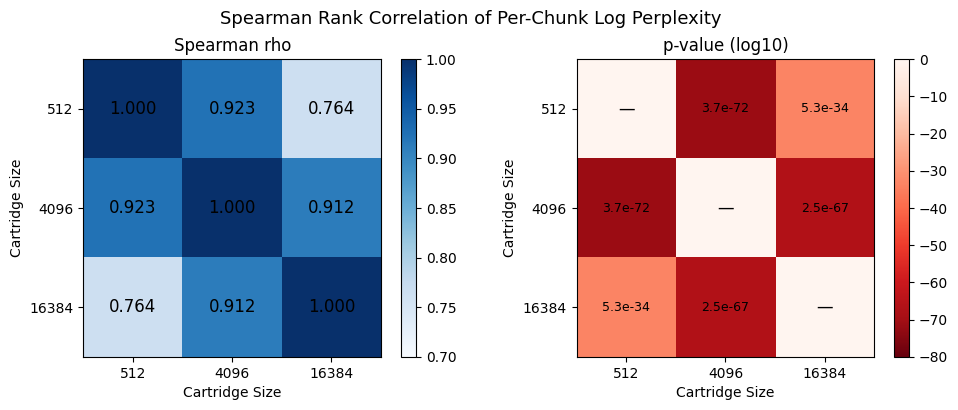

In [4]:
from scipy.stats import spearmanr
import itertools

# Extract avg_loss vectors for each cartridge size
losses = {}
for size, d in data.items():
    losses[size] = np.array([r["avg_loss"] for r in d["results"]])

# Pairwise Spearman rank correlation
sizes = list(losses.keys())
print("Pairwise Spearman Rank Correlation (avg_loss across chunks):\n")
for a, b in itertools.combinations(sizes, 2):
    rho, pval = spearmanr(losses[a], losses[b])
    print(f"  Cartridge {a:>5} vs {b:>5}:  rho = {rho:.4f},  p = {pval:.2e}")

# Compute both rho and p-value matrices
corr_matrix = np.ones((len(sizes), len(sizes)))
pval_matrix = np.zeros((len(sizes), len(sizes)))
for i, a in enumerate(sizes):
    for j, b in enumerate(sizes):
        if i != j:
            corr_matrix[i, j], pval_matrix[i, j] = spearmanr(losses[a], losses[b])

# Plot side by side: rho and p-value
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Rho heatmap
im1 = ax1.imshow(corr_matrix, cmap="Blues", vmin=0.7, vmax=1.0)
ax1.set_xticks(range(len(sizes)))
ax1.set_yticks(range(len(sizes)))
ax1.set_xticklabels([str(s) for s in sizes])
ax1.set_yticklabels([str(s) for s in sizes])
ax1.set_xlabel("Cartridge Size")
ax1.set_ylabel("Cartridge Size")
ax1.set_title("Spearman rho")
for i in range(len(sizes)):
    for j in range(len(sizes)):
        ax1.text(j, i, f"{corr_matrix[i, j]:.3f}", ha="center", va="center", fontsize=12)
plt.colorbar(im1, ax=ax1)

# P-value heatmap (log scale)
log_pvals = np.where(pval_matrix > 0, np.log10(pval_matrix), 0)
im2 = ax2.imshow(log_pvals, cmap="Reds_r", vmin=-80, vmax=0)
ax2.set_xticks(range(len(sizes)))
ax2.set_yticks(range(len(sizes)))
ax2.set_xticklabels([str(s) for s in sizes])
ax2.set_yticklabels([str(s) for s in sizes])
ax2.set_xlabel("Cartridge Size")
ax2.set_ylabel("Cartridge Size")
ax2.set_title("p-value (log10)")
for i in range(len(sizes)):
    for j in range(len(sizes)):
        if i == j:
            ax2.text(j, i, "—", ha="center", va="center", fontsize=12)
        else:
            ax2.text(j, i, f"{pval_matrix[i, j]:.1e}", ha="center", va="center", fontsize=9)
plt.colorbar(im2, ax=ax2)

fig.suptitle("Spearman Rank Correlation of Per-Chunk Log Perplexity", fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
# Top-K highest perplexity chunks for each cartridge size
# Using the 16384 cartridge as the reference (cleanest signal)

K = 10
ref_size = 4096
results = data[ref_size]["results"]

# Sort by avg_loss descending
sorted_chunks = sorted(results, key=lambda r: r["avg_loss"], reverse=True)

print(f"Top {K} highest perplexity chunks (Cartridge {ref_size} tokens)")
print(f"Threshold reference: mean={np.mean([r['avg_loss'] for r in results]):.2f}, "
      f"std={np.std([r['avg_loss'] for r in results]):.2f}, "
      f"mean+1std={np.mean([r['avg_loss'] for r in results]) + np.std([r['avg_loss'] for r in results]):.2f}")
print("=" * 100)

for rank, chunk in enumerate(sorted_chunks[:K], 1):
    # Also show what the other cartridge sizes say about this chunk
    idx = chunk["chunk_idx"]
    losses_at_idx = {s: data[s]["results"][idx]["avg_loss"] for s in [512, 4096, 16384]}
    
    print(f"\n--- Rank {rank} | Chunk {idx} | Tokens {chunk['start_token']}-{chunk['end_token']} ---")
    print(f"  avg_loss:  512={losses_at_idx[512]:.3f}  |  4096={losses_at_idx[4096]:.3f}  |  16384={losses_at_idx[16384]:.3f}")
    print(f"  Text preview:")
    print(f"  {chunk['text_preview']}...")
    print()

Top 10 highest perplexity chunks (Cartridge 4096 tokens)
Threshold reference: mean=1.38, std=0.62, mean+1std=2.00

--- Rank 1 | Chunk 14 | Tokens 7168-7680 ---
  avg_loss:  512=3.519  |  4096=3.666  |  16384=3.310
  Text preview:
   include Spartan-6, Spartan-3, the Spartan-3E and Spartan-3A, Spartan-IIE, Spartan-II, Spartan XL
and the original Spartan family. Complex Programmable Logic Devices (CPLDs) operate on the lowest end of the programmable logic density spectrum. CPLDs
are single-chip, nonvolatile solutions characterized by instant-on and universal interconnect. Prior generations of CPLDs include the CoolRunner™ and XC9500
product families.
Design Platforms and Services
Adaptable Platforms. We offer two types of platforms that support our customers' designs and reduce their development efforts: FPGAs and Adaptive SoCs.
All devices feature adaptable hardware that enables our customers to implement customized, domain-specific architectures. With both hardware-accelerated
performa